# Sentiment Analysis Machine Learning Project

In [4]:
import numpy as np 
import pandas as pd 

# For Visualization 
import matplotlib.pyplot as plt 
import seaborn as sns 
from wordcloud import WordCloud 
from collections import Counter 

# For Text Processing 
import re 
import string 
from sklearn.model_selection import train_test_split 
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer 

# For Models 
from sklearn.linear_model import LogisticRegression 
from sklearn.naive_bayes import MultinomialNB 
from sklearn.svm import LinearSVC 
from sklearn.ensemble import RandomForestClassifier 

# For Evaluation 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report 
import joblib 

# Ignore Warnings 
import warnings 
warnings.filterwarnings("ignore") 

# For Plot Settings 
sns.set_theme(style="whitegrid") 
plt.rcParams["figure.figsize"] = (8,5) 

df = pd.read_csv("sentimentdataset.csv") 
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


***Laod the Dataset***

In [5]:
df = pd.read_csv("sentimentdataset.csv")
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


In [6]:
# Dataset info

print("\n Dataset Information:") 
df.info()


 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  732 non-null    int64  
 1   Unnamed: 0    732 non-null    int64  
 2   Text          732 non-null    object 
 3   Sentiment     732 non-null    object 
 4   Timestamp     732 non-null    object 
 5   User          732 non-null    object 
 6   Platform      732 non-null    object 
 7   Hashtags      732 non-null    object 
 8   Retweets      732 non-null    float64
 9   Likes         732 non-null    float64
 10  Country       732 non-null    object 
 11  Year          732 non-null    int64  
 12  Month         732 non-null    int64  
 13  Day           732 non-null    int64  
 14  Hour          732 non-null    int64  
dtypes: float64(2), int64(6), object(7)
memory usage: 85.9+ KB


In [7]:
# Check Missing Values
print("\n Missing Values:")
print(df.isnull().sum())


 Missing Values:
Unnamed: 0.1    0
Unnamed: 0      0
Text            0
Sentiment       0
Timestamp       0
User            0
Platform        0
Hashtags        0
Retweets        0
Likes           0
Country         0
Year            0
Month           0
Day             0
Hour            0
dtype: int64


In [8]:
# Sentiment Labels
print("]n Sentiment Classifier:")
print(df['Sentiment'].value_counts())

]n Sentiment Classifier:
Sentiment
Positive               44
Joy                    42
Excitement             32
Happy                  14
Neutral                14
                       ..
Vibrancy                1
Culinary Adventure      1
Mesmerizing             1
Thrilling Journey       1
Winter Magic            1
Name: count, Length: 279, dtype: int64


***Exploratory Data Analysis***

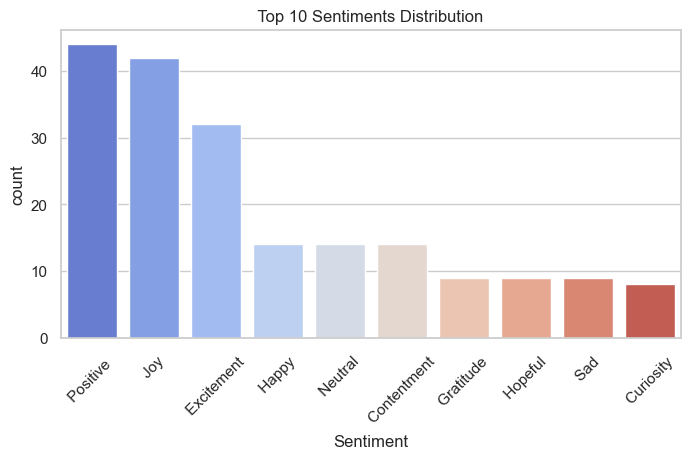

In [9]:
# Top 10 Sentiments
top_sentiments =  df['Sentiment'].value_counts().nlargest(10).index
df_top = df[df['Sentiment'].isin(top_sentiments)]

# Distribution of Sentiments
plt.figure(figsize=(8,4))
sns.countplot(data=df_top, x='Sentiment', palette='coolwarm',order=top_sentiments)
plt.title(' Top 10 Sentiments Distribution ' )
plt.xticks(rotation=45)
plt.show()

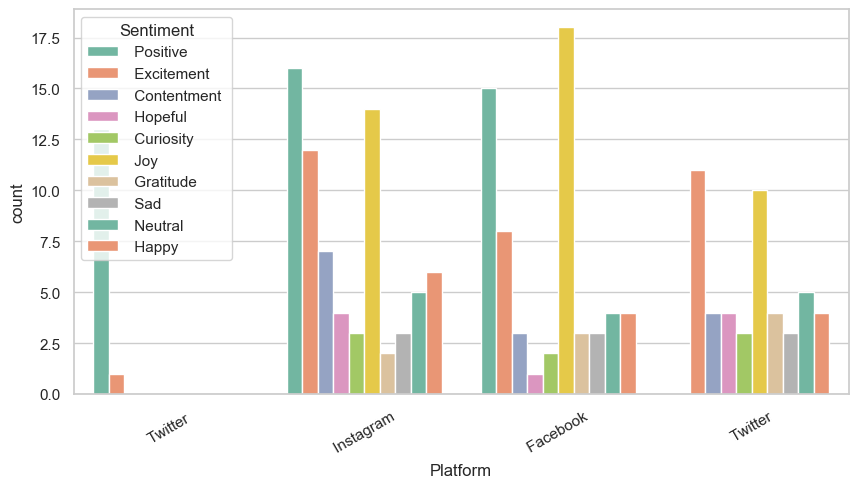

In [10]:
# Sentiment Analysis - Platform Wise
plt.figure(figsize=(10,5))
sns.countplot(data=df_top, x='Platform', hue='Sentiment', palette='Set2')
plt.xticks(rotation=30)
plt.show()

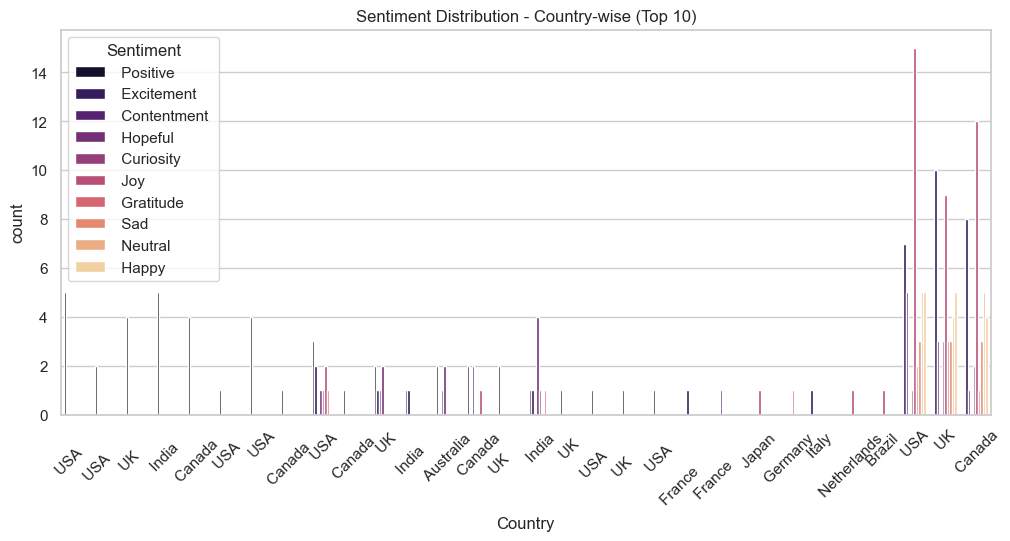

In [11]:
# Sentiment Analysis- Country Wise
plt.figure(figsize=(12,5))
sns.countplot(data=df_top, x='Country',hue='Sentiment',palette='magma')
plt.title('Sentiment Distribution - Country-wise (Top 10)')
plt.xticks(rotation=45)
plt.show()

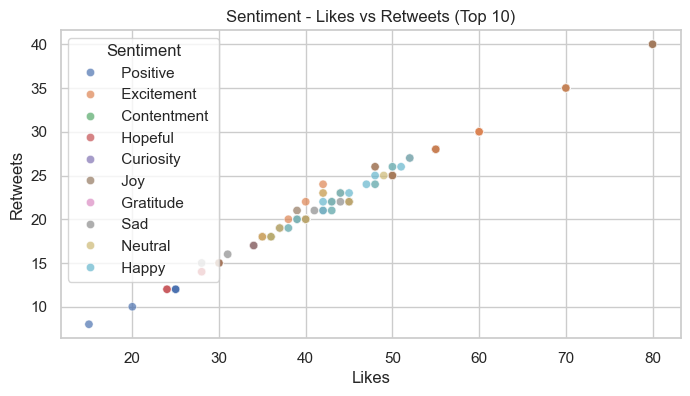

In [12]:
# Likes vs Retweets
plt.figure(figsize=(8,4))
sns.scatterplot(data=df_top, x='Likes', y='Retweets',hue='Sentiment', alpha=0.7)
plt.title('Sentiment - Likes vs Retweets (Top 10)')
plt.show()

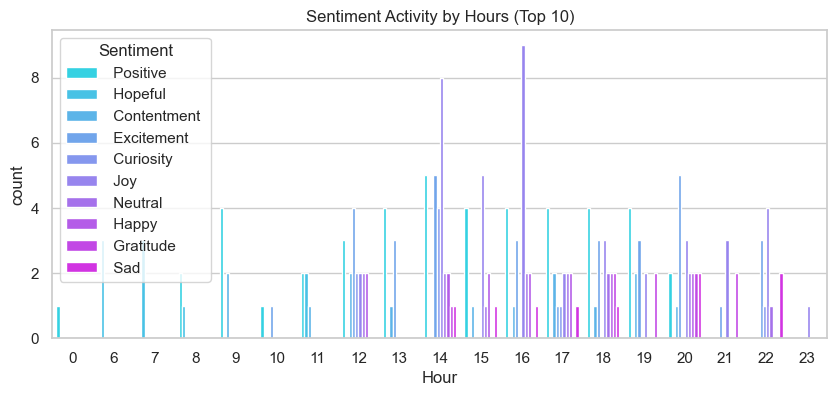

In [13]:
# Sentiment Trend Over Hours
plt.figure(figsize=(10,4))
sns.countplot(data=df_top,x='Hour',hue='Sentiment',palette='cool')
plt.title('Sentiment Activity by Hours (Top 10)')
plt.show()

***Texting CLeaning & Preprocessing***

In [14]:
import nltk 
from nltk.corpus import stopwords

nltk.download('stopwords') 
stop_words = set(stopwords.words('english')) 

def clean_text(text): 
    text = str(text).lower() 
    text = re.sub(r"http\S+", "", text)      # to remove URLs 
    text = re.sub(r"@\w+", "", text)         # to remove mentions 
    text = re.sub(r"#\w+", "", text)         # to remove hastags 
    text = re.sub(r"[^a-z\s]", "", text)     # to keep only letters 
    text = " ".join([word for word in text.split() if word not in stop_words]) 
    return text.strip() 
    
df['Clean_Text'] = df['Text'].apply(clean_text) 
df[['Text', 'Clean_Text']].head(10)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\harsh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Text,Clean_Text
0,Enjoying a beautiful day at the park! ...,enjoying beautiful day park
1,Traffic was terrible this morning. ...,traffic terrible morning
2,Just finished an amazing workout! 💪 ...,finished amazing workout
3,Excited about the upcoming weekend getaway! ...,excited upcoming weekend getaway
4,Trying out a new recipe for dinner tonight. ...,trying new recipe dinner tonight
5,Feeling grateful for the little things in lif...,feeling grateful little things life
6,Rainy days call for cozy blankets and hot coc...,rainy days call cozy blankets hot cocoa
7,The new movie release is a must-watch! ...,new movie release mustwatch
8,Political discussions heating up on the timel...,political discussions heating timeline
9,Missing summer vibes and beach days. ...,missing summer vibes beach days


***Text Analysis***

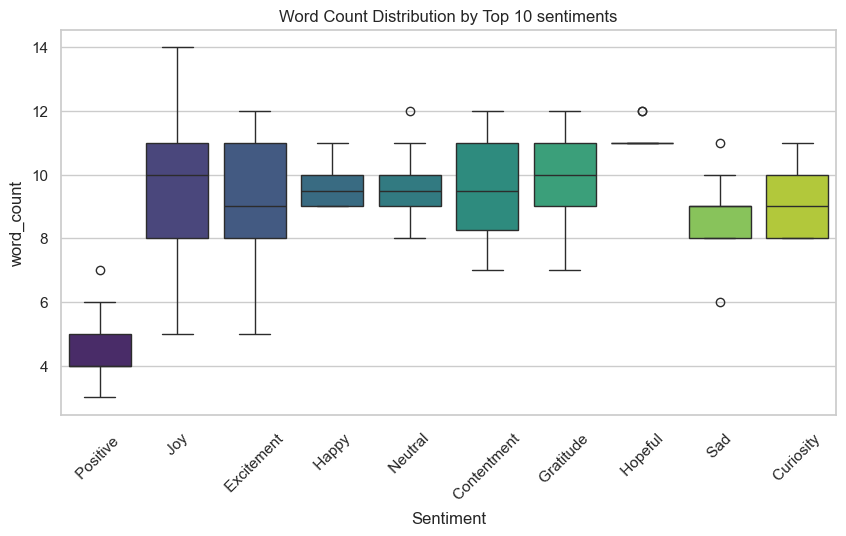


Top Words for  Positive  :


,Words,Frequency
0,new,10
1,day,4
2,weekend,4
3,feeling,4
4,enjoying,3



Top Words for  Joy :


,Words,Frequency
0,music,7
1,art,7
2,joy,6
3,every,6
4,attended,6



Top Words for  Excitement :


...

,Words,Frequency
0,hopeful,8
1,optimism,6
2,brighter,5
3,tomorrow,5
4,towards,4



Top Words for  Sad :


,Words,Frequency
0,feeling,5
1,challenges,2
2,sometimes,2
3,unexpected,2
4,missing,2



Top Words for  Curiosity :


,Words,Frequency
0,new,4
1,curiosity,2
2,art,2
3,learning,2
4,unveiling,1


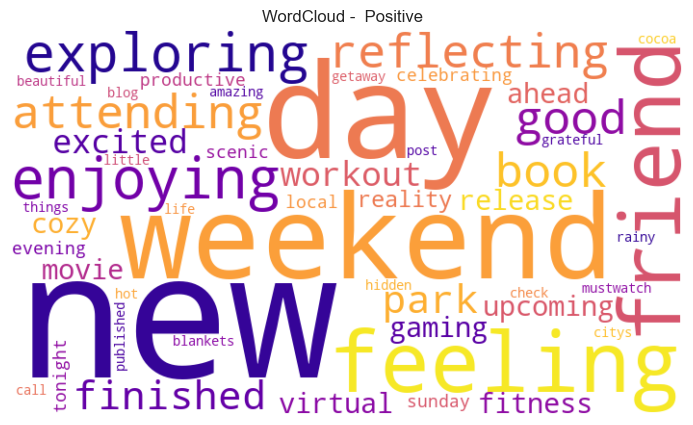

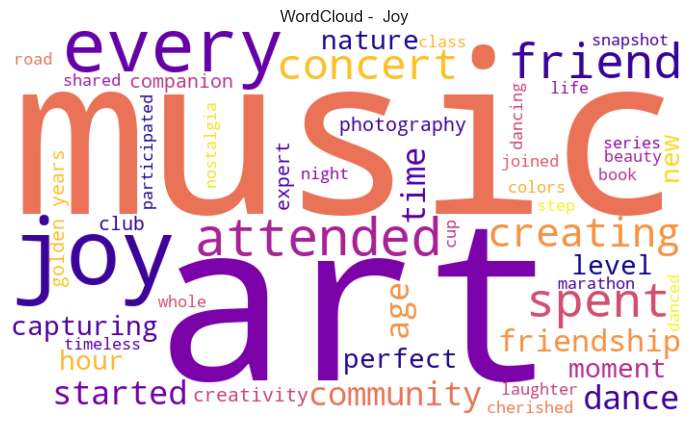

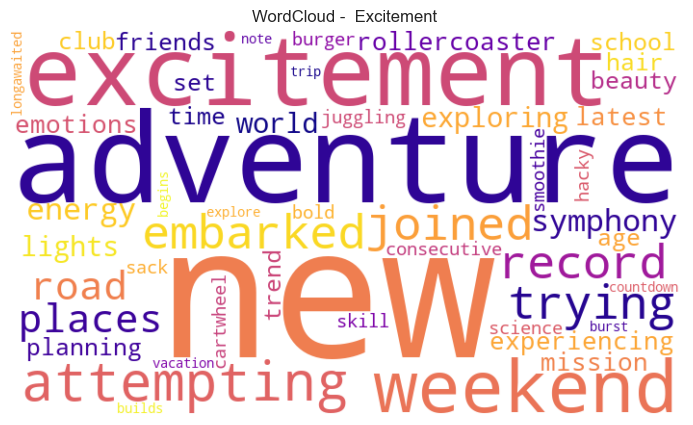

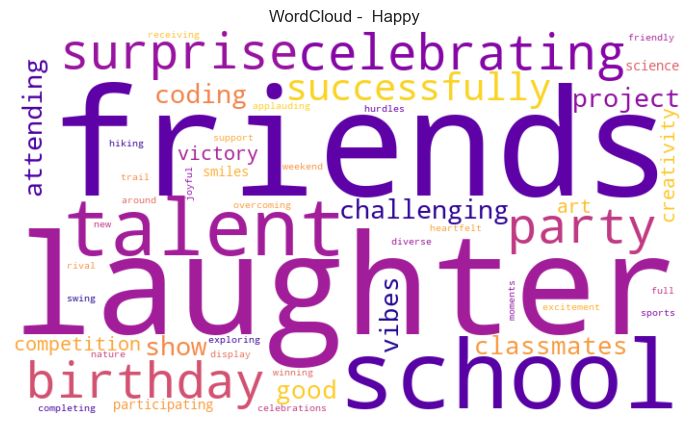

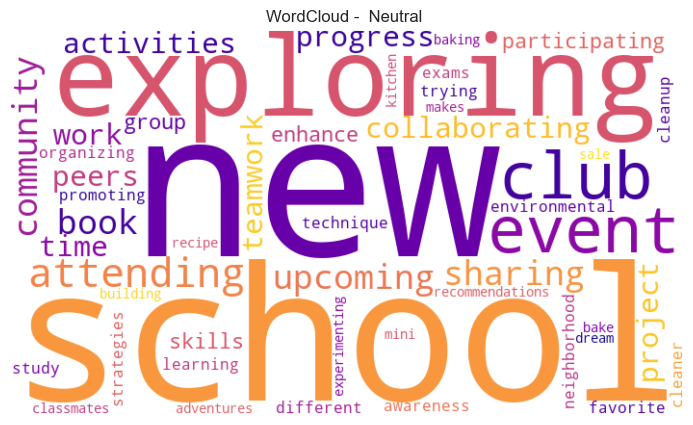

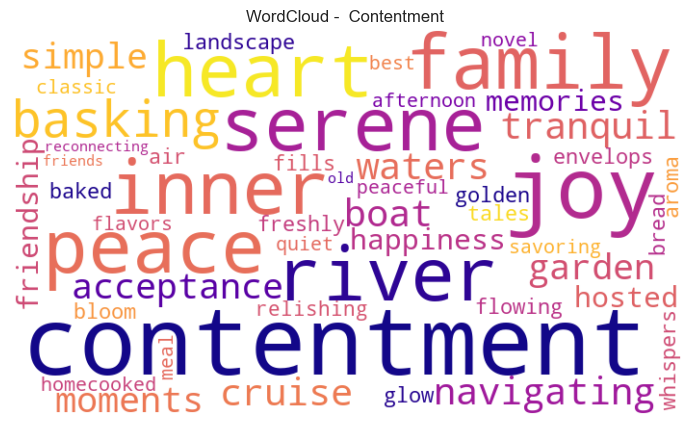

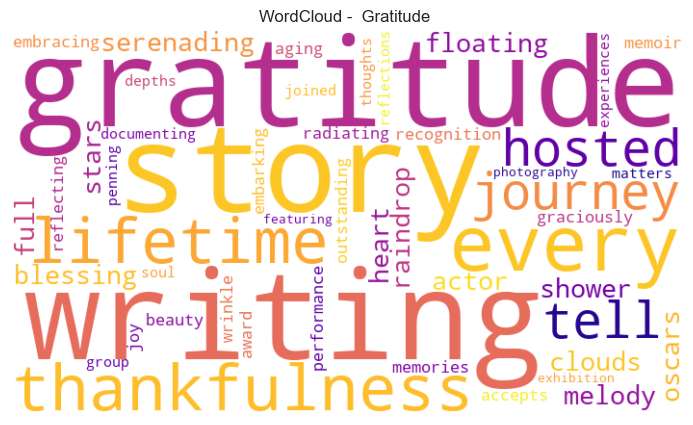

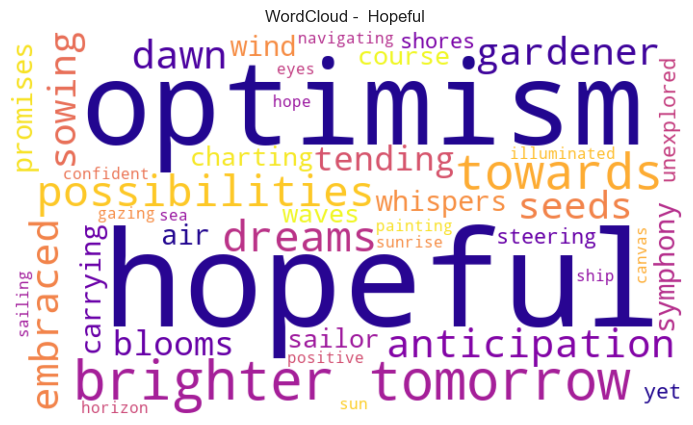

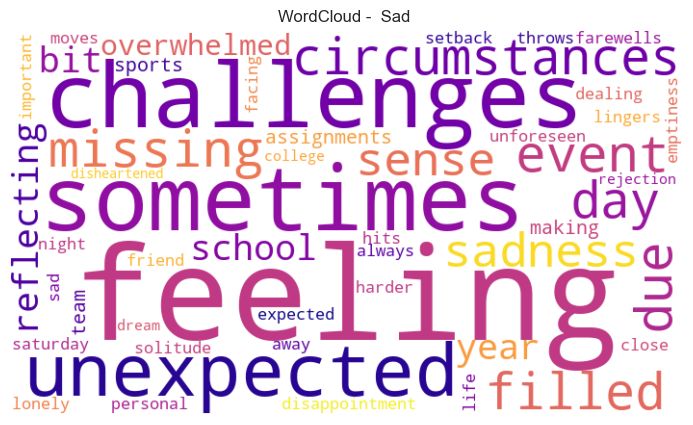

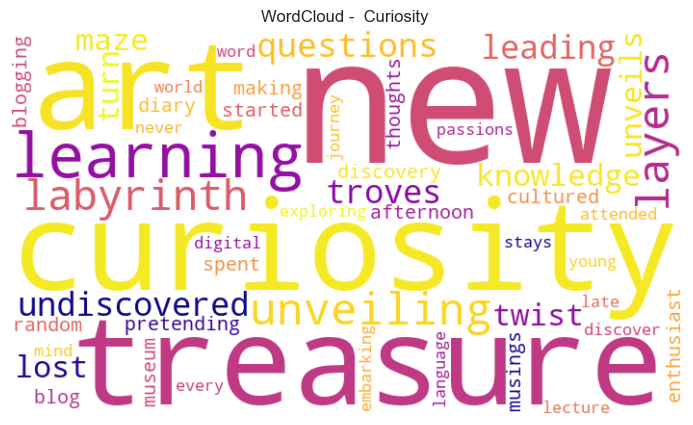

In [15]:
# Select Top 10 most frequent sentiments
top_sentiments  = df['Sentiment'].value_counts().nlargest(10).index
df_top = df[df['Sentiment'].isin(top_sentiments)]

# Average Word Count per Sentiments (Top 10)
df_top['word_count'] = df_top['Clean_Text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10,5))
sns.boxplot(data=df_top, x='Sentiment', y='word_count',palette='viridis', order=top_sentiments)
plt.title('Word Count Distribution by Top 10 sentiments')
plt.xticks(rotation=45)
plt.show()

# Most Common Words Per Sentiments (Top 10 Sentiments, Top 5 words each
def most_common_words(sentiment,n=5):
    words = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text']).split()
    common = Counter(words).most_common(n)
    return pd.DataFrame(common, columns=['Words','Frequency'])

for s in top_sentiments:
    print(f"\nTop Words for {s}:")
    display(most_common_words(s, n=5)) #only top 5 words

# WordClouds for Top 10 Sentiments
for sentiment in top_sentiments:
    text = " ".join(df_top[df_top['Sentiment']==sentiment]['Clean_Text'])
    wc = WordCloud(width=700,  height=400, background_color='white', colormap='plasma', max_words=50).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {sentiment}")
    plt.show()

***Feature Extraction***

In [16]:
# Combine rare classes with <2 samples into 'Other'

counts = df['Sentiment'].value_counts()
rare_classes = counts[counts < 2].index
df['Sentiment'] = df['Sentiment'].replace(rare_classes, 'Other')

# TF-IDF
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95
)
X = tfidf.fit_transform(df['Clean_Text'])
y = df['Sentiment']

# Train/Test Split with Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test Shape:", X_test.shape)

Train shape: (585, 1758) Test Shape: (147, 1758)


***Model Training and Comparision***

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Navie Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy {acc:4f}")

Logistic Regression Accuracy 0.217687
Navie Bayes Accuracy 0.197279
Linear SVM Accuracy 0.462585
Random Forest Accuracy 0.435374


***Visual Comparison of Model Accracies***

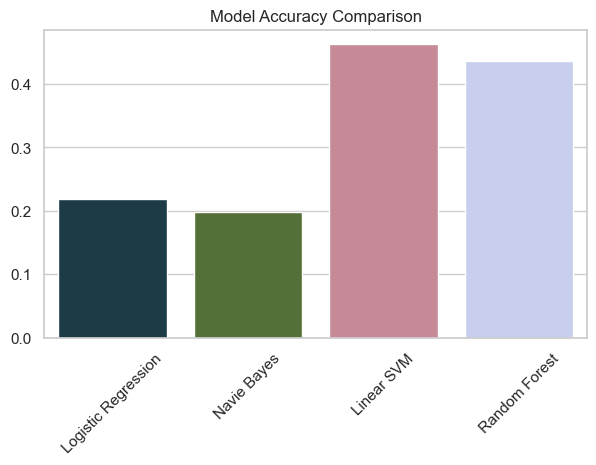


 Best Performing Model: Linear SVM (46.26% accuracy)


In [18]:
plt.figure(figsize=(7,4))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='cubehelix')
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=45)
plt.show()

best_model_name = max(results, key= results.get)
print(f"\n Best Performing Model: {best_model_name} ({results[best_model_name]:.2%} accuracy)")

***Detailed Evaluation of Best Model***

In [19]:
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best))


Classification Report:
                   precision    recall  f1-score   support

    Acceptance          0.00      0.00      0.00         1
 Acceptance             0.50      1.00      0.67         1
  Accomplishment        0.00      0.00      0.00         1
    Adoration           1.00      1.00      1.00         1
       Adventure        0.00      0.00      0.00         1
 Ambivalence            1.00      1.00      1.00         1
    Anticipation        0.00      0.00      0.00         0
   Arousal              1.00      1.00      1.00         1
             Awe        0.00      0.00      0.00         1
             Bad        1.00      1.00      1.00         1
        Betrayal        0.50      1.00      0.67         1
    Bitter              0.50      1.00      0.67         1
      Bitterness        1.00      1.00      1.00         1
 Boredom                1.00      1.00      1.00         1
    Calmness            0.00      0.00      0.00         1
     Captivation        0.00   

***Save Best Model and Vectorizer***

In [20]:
import joblib

joblib.dump(best_model, "best_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("\n Model and TF-IDF Vectorizer saved successfully!")


 Model and TF-IDF Vectorizer saved successfully!


***Predict Sentiment on New Text***

In [21]:
def predict_sentiment(text):
    clean = clean_text(text)
    vec = tfidf.transform([clean])
    pred = best_model.predict(vec)[0]
    return pred

# Example Predictions
samples = [
    "I Love this new features!",
    "Thhe service was awful and slow.",
    "It's okay, not too bad but not great either."
]

for s in samples:
    print(f"Text: {s} -> Sentiment: {predict_sentiment(s)}")

Text: I Love this new features! -> Sentiment:  Love         
Text: Thhe service was awful and slow. -> Sentiment:  Disappointed 
Text: It's okay, not too bad but not great either. -> Sentiment:  Bad 


***Export Cleanned Dataset***

In [22]:
df.to_csv("cleanned_sentiment_dataset.csv", index=False)
print("Cleanned datasert saved sucessfully!")

Cleanned datasert saved sucessfully!
